# 실습 9: 혼동행렬과 분류 결과 리포트
- 상황: 정확도 하나로는 어느 모델이 나은지 답할 수 없다
- 목표: 틀린 것을 두 종류로 나눠 보고, 오늘 결과를 리포트 한 장으로 마감한다

## Step 0. 앞 실습까지 재현하기 (로지스틱 회귀)

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("../../day02/lab06_clean-dataset/results/secom_clean.csv")

sensor_cols = df.columns.drop("result")
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].median())

df["불량여부"] = (df["result"] == "불량").astype(int)

X = df[sensor_cols]
y = df["불량여부"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 로지스틱 회귀는 단위를 맞춰야 하므로 StandardScaler로 표준화한다
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# class_weight 등 불균형 보정 없이 기본 설정 그대로 사용한다
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

예측 = model.predict(X_test_scaled)

정확도 = (예측 == y_test).mean() * 100

print("학습용:", X_train.shape[0], "건, 불량", int(y_train.sum()), "건")
print("시험용:", X_test.shape[0], "건, 불량", int(y_test.sum()), "건")
print("정확도:", round(정확도, 2), "%")

학습용: 1253 건, 불량 83 건
시험용: 314 건, 불량 21 건
정확도: 92.99 %


---

## Step 1. 오늘 쓸 말 정리하기

### 용어 풀이 - 결과를 네 칸으로 나눠 볼 때 쓰는 말

| 말 | 뜻 |
|---|---|
| 혼동행렬 | 맞힌 것과 틀린 것을 네 칸으로 나눠 놓은 표 |
| 놓친 불량 | 불량인데 양품이라 한 것. 걸러지지 않고 고객에게 간다 |
| 헛경보 | 양품인데 불량이라 한 것. 멀쩡한 것을 세워 다시 본다 |
| 재현율 (recall) | 실제 불량 중 몇 %를 잡았나 |
| 정밀도 (precision) | 불량이라 한 것 중 진짜가 몇 %였나 |
| F1 | 재현율과 정밀도를 함께 보는 값. 한쪽만 좋으면 오르지 않는다 |

---

## Step 2. 네 칸으로 쪼개기

In [28]:
# confusion_matrix - 실제 답과 예측을 맞대어 네 칸으로 세어준다
from sklearn.metrics import confusion_matrix

행렬 = confusion_matrix(y_test, 예측)
print(행렬)

# ravel() - 네 칸을 한 줄로 펴서 하나씩 이름을 붙여 받는다
# 순서가 정해져 있다: 왼쪽위, 오른쪽위, 왼쪽아래, 오른쪽아래
맞힌양품, 헛경보, 놓친불량, 잡은불량 = 행렬.ravel()

print("양품인데 양품이라 함 :", 맞힌양품)
print("양품인데 불량이라 함 :", 헛경보,   " <- 헛경보")
print("불량인데 양품이라 함 :", 놓친불량, " <- 놓친 불량")
print("불량인데 불량이라 함 :", 잡은불량)

[[290   3]
 [ 19   2]]
양품인데 양품이라 함 : 290
양품인데 불량이라 함 : 3  <- 헛경보
불량인데 양품이라 함 : 19  <- 놓친 불량
불량인데 불량이라 함 : 2


---

## Step 3. 네 칸이 현장에서 무슨 상황인가

| 칸 | 내 숫자 | 현장에서는 |
|---|---|---|
| 양품인데 양품 | [290] | 아무 일 없음 |
| 양품인데 불량 (헛경보) | [3] | 멀쩡한 걸 세우고 다시 본다. 사람 손이 든다 |
| 불량인데 양품 (놓친 불량) | [19] | 걸러지지 않고 고객에게 간다 |
| 불량인데 불량 | [2] | 원하던 것. 미리 잡았다 |

---

## Step 4. 두 지표를 손으로 계산하기

In [29]:
# 재현율 - 실제 불량 중 몇 %를 잡았나
# 분모는 "실제 불량 전체" = 잡은 것 + 놓친 것
재현율 = 잡은불량 / (잡은불량 + 놓친불량)

# 정밀도 - 불량이라 한 것 중 진짜가 몇 %였나
# 분모는 "불량이라고 한 것 전체" = 진짜 + 헛경보
정밀도 = 잡은불량 / (잡은불량 + 헛경보)

print("재현율:", round(재현율, 3), " <- 실제 불량", 잡은불량 + 놓친불량, "건 중", 잡은불량, "건")
print("정밀도:", round(정밀도, 3), " <- 불량이라 한", 잡은불량 + 헛경보, "건 중", 잡은불량, "건")

재현율: 0.095  <- 실제 불량 21 건 중 2 건
정밀도: 0.4  <- 불량이라 한 5 건 중 2 건


### 문법 노트 - 네 칸에서 지표 뽑기

| 쓴 것 | 하는 일 | 왜 여기 쓰나 |
|---|---|---|
| confusion_matrix(실제, 예측) | 맞고 틀림을 네 칸으로 세어준다 | 정확도 하나로는 안 보이는 걸 본다 |
| .ravel() | 네 칸을 한 줄로 펴준다 | 칸마다 이름을 붙여 받으려고 |
| classification_report | 지표를 한 번에 계산해 표로 보여준다 | 손으로 구한 값과 맞춰보려고 |

**분자는 둘 다 같고 분모가 다르다.**<br>
재현율 = 잡은불량 / (잡은불량 + 놓친불량)   분모가 "실제 불량 전체"<br>
정밀도 = 잡은불량 / (잡은불량 + 헛경보)     분모가 "불량이라 한 것 전체"<br>
헷갈리면 분모부터 정하면 된다.

---

## Step 5. 라이브러리 출력과 대조하기

In [30]:
from sklearn.metrics import classification_report

# target_names - 0과 1 대신 사람이 읽을 이름을 붙인다
# digits=3 - 소수점 셋째 자리까지
print(classification_report(y_test, 예측,
                            target_names=["양품", "불량"], digits=3))

              precision    recall  f1-score   support

          양품      0.939     0.990     0.963       293
          불량      0.400     0.095     0.154        21

    accuracy                          0.930       314
   macro avg      0.669     0.542     0.559       314
weighted avg      0.902     0.930     0.909       314



---

## Step 6. 기준 모델의 재현율은 얼마인가

In [31]:
import warnings
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

# 전부 양품(0)이라고만 답하는 기준 모델을 다시 만든다
기준예측 = np.zeros(len(y_test), dtype=int)

def 지표계산(pred):
    정확도 = accuracy_score(y_test, pred) * 100
    재현율 = recall_score(y_test, pred, zero_division=0)
    정밀도 = precision_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return 정확도, 재현율, 정밀도, f1, fn, fp

# 기준 모델은 불량(1)이라고 한 것이 0건이라 정밀도의 분모(TP+FP)가 0이 된다.
# zero_division 옵션 없이 그대로 계산하면 어떤 경고가 실제로 뜨는지 직접 확인한다
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    _ = precision_score(y_test, 기준예측)
    경고메시지 = str(w[0].message) if w else "(경고가 뜨지 않음)"

기준_지표 = 지표계산(기준예측)
모델_지표 = 지표계산(예측)

비교표 = pd.DataFrame(
    [
        {
            "모델": "기준 모델 (전부 양품)",
            "정확도(%)": round(기준_지표[0], 2),
            "재현율": round(기준_지표[1], 3),
            "정밀도": round(기준_지표[2], 3),
            "F1": round(기준_지표[3], 3),
            "놓친 불량": int(기준_지표[4]),
            "헛경보": int(기준_지표[5]),
        },
        {
            "모델": "로지스틱 회귀",
            "정확도(%)": round(모델_지표[0], 2),
            "재현율": round(모델_지표[1], 3),
            "정밀도": round(모델_지표[2], 3),
            "F1": round(모델_지표[3], 3),
            "놓친 불량": int(모델_지표[4]),
            "헛경보": int(모델_지표[5]),
        },
    ]
).set_index("모델")

print("[기준 모델의 정밀도를 zero_division 없이 계산할 때 뜨는 경고]")
print(경고메시지)
print()

비교표

[기준 모델의 정밀도를 zero_division 없이 계산할 때 뜨는 경고]
Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



,정확도(%),재현율,정밀도,F1,놓친 불량,헛경보
모델,,,,,,
기준 모델 (전부 양품),93.31,0.000,0.0,0.000,21,0
로지스틱 회귀,92.99,0.095,0.4,0.154,19,3


**경고 설명**<br>
(해석)<br>
정밀도(Precision)는 정의할 수 없는 상태라 0.0으로 처리됩니다. 예측된(양성으로 분류된) 샘플이 하나도 없기 때문입니다. 이 동작 방식을 직접 지정하려면 zero_division 매개변수를 사용하세요.

(풀이)<br>
 정밀도 = (진짜 불량으로 맞힌 것) / (불량이라고 예측한 것 전체)인데, 이 모델은 불량이라고 예측한 게 0건이라 분모가 0이 됩니다. 0으로 나누는 계산은 수학적으로 정의되지 않으므로("ill-defined"), sklearn이 임의로 0.0을 대신 넣어주면서 "이게 맞는지 확인하고 싶으면 zero_division 옵션을 직접 지정하라"고 경고하는 것입니다.

---

## Step 7. 문턱을 낮춰 더 잡아보기

In [32]:
# 모델은 다시 학습시키지 않고, predict_proba로 "불량일 가능성"만 뽑아 문턱만 바꿔본다
확률 = model.predict_proba(X_test_scaled)[:, 1]

문턱별결과 = []
for 문턱 in [0.5, 0.3, 0.2, 0.1]:
    예측_문턱 = (확률 >= 문턱).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, 예측_문턱).ravel()
    재현율_문턱 = recall_score(y_test, 예측_문턱, zero_division=0)
    정밀도_문턱 = precision_score(y_test, 예측_문턱, zero_division=0)

    문턱별결과.append({
        "문턱": 문턱,
        "잡은 불량": int(tp),
        "놓친 불량": int(fn),
        "헛경보": int(fp),
        "재현율": round(재현율_문턱, 3),
        "정밀도": round(정밀도_문턱, 3),
    })

문턱표 = pd.DataFrame(문턱별결과).set_index("문턱")
문턱표

,잡은 불량,놓친 불량,헛경보,재현율,정밀도
문턱,,,,,
0.5,2,19,3,0.095,0.400
0.3,3,18,8,0.143,0.273
0.2,4,17,15,0.190,0.211
0.1,7,14,43,0.333,0.140


### 문턱을 낮추면

| 문턱 | 잡은 불량 | 놓친 불량 | 헛경보 | 재현율 | 정밀도 |
|---|---|---|---|---|---|
| 0.5 | [2] | [19] | [3] | [0.095] | [0.400] |
| 0.3 | [3] | [18] | [8] | [0.143] | [0.273] |
| 0.2 | [4] | [17] | [15] | [0.190] | [0.211] |
| 0.1 | [7] | [14] | [43] | [0.333] | [0.140] |

---

## Step 8. 분류 결과 리포트 마감하기

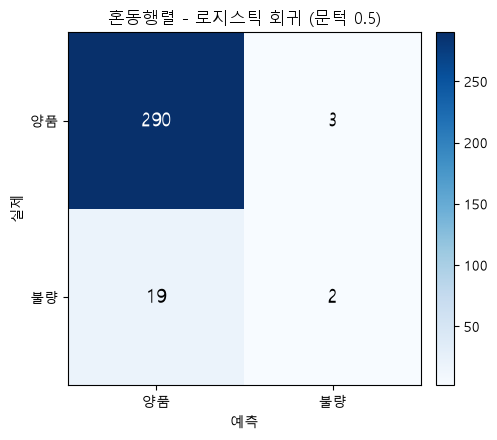

저장 위치: c:\Users\subin\OneDrive\바탕 화면\secome-project\day03\lab09_confusion-matrix\results\confusion_matrix.png


In [33]:
# 이미 실행된 결과(맞힌양품, 헛경보, 놓친불량, 잡은불량)를 그대로 그림으로 그린다
import matplotlib.pyplot as plt
import os

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

행렬_그림용 = np.array([[맞힌양품, 헛경보], [놓친불량, 잡은불량]])

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(행렬_그림용, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["양품", "불량"])
ax.set_yticklabels(["양품", "불량"])
ax.set_xlabel("예측")
ax.set_ylabel("실제")
ax.set_title("혼동행렬 - 로지스틱 회귀 (문턱 0.5)")

for i in range(2):
    for j in range(2):
        ax.text(
            j, i, str(행렬_그림용[i, j]),
            ha="center", va="center", fontsize=14,
            color="white" if 행렬_그림용[i, j] > 행렬_그림용.max() / 2 else "black",
        )

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()

os.makedirs("results", exist_ok=True)
그림경로 = os.path.join("results", "confusion_matrix.png")
fig.savefig(그림경로, dpi=150)
plt.show()

print("저장 위치:", os.path.abspath(그림경로))

In [34]:
# report.md에 쓸 값은 전부 이 노트북에서 이미 계산된 변수에서 그대로 가져온다 (새로 묻지 않는다)

# 1. 데이터 - Step 0에서 읽은 정제본을 다시 읽어 원래 행/열 수를 그대로 확인한다
원본 = pd.read_csv("../../day02/lab06_clean-dataset/results/secom_clean.csv")
원본_행수, 원본_열수 = 원본.shape
전체_불량비율 = round(y.mean() * 100, 2)

학습용_건수 = int(X_train.shape[0])
학습용_불량 = int(y_train.sum())
시험용_건수 = int(X_test.shape[0])
시험용_불량 = int(y_test.sum())

# 2. 모델 - Step 0에서 학습시킨 model 객체에서 그대로 읽는다
모델이름 = type(model).__name__
전처리설명 = "StandardScaler (학습용에 fit, 시험용은 transform만 적용)"
class_weight값 = model.class_weight

def df_to_md(표):
    cols = list(표.columns)
    줄들 = ["| " + " | ".join(cols) + " |", "|" + "|".join(["---"] * len(cols)) + "|"]
    for _, row in 표.iterrows():
        줄들.append("| " + " | ".join(str(v) for v in row.tolist()) + " |")
    return "\n".join(줄들)

# 3. 결과 표 - Step 6에서 만든 비교표를 그대로 가져온다
결과표_md = df_to_md(비교표.reset_index())

# 4. 혼동행렬 네 칸 - Step 2에서 이미 계산된 값을 그대로 가져온다
맞힌양품_i, 헛경보_i, 놓친불량_i, 잡은불량_i = int(맞힌양품), int(헛경보), int(놓친불량), int(잡은불량)

# 5. 문턱별 비교표 - Step 7에서 만든 문턱표를 그대로 가져온다
문턱표_md = df_to_md(문턱표.reset_index())

report_md = f"""# 실습 9 분류 결과 리포트

## 1. 데이터
| 항목 | 값 |
|---|---|
| 정제본 행 수 | {원본_행수} |
| 정제본 열 수 | {원본_열수} |
| 불량 비율(%) | {전체_불량비율} |
| 학습용 건수 | {학습용_건수} (불량 {학습용_불량}) |
| 시험용 건수 | {시험용_건수} (불량 {시험용_불량}) |

## 2. 모델
| 항목 | 값 |
|---|---|
| 모델 | {모델이름} |
| 전처리 | {전처리설명} |
| class_weight | {class_weight값} |

## 3. 결과 표
{결과표_md}

## 4. 혼동행렬 (문턱 0.5)
| 칸 | 건수 |
|---|---|
| 양품 → 양품 | {맞힌양품_i} |
| 양품 → 불량 (헛경보) | {헛경보_i} |
| 불량 → 양품 (놓친 불량) | {놓친불량_i} |
| 불량 → 불량 (잡은 불량) | {잡은불량_i} |

## 5. 문턱별 비교표
{문턱표_md}

## 6. 그림
- confusion_matrix.png
"""

os.makedirs("results", exist_ok=True)
리포트경로 = os.path.join("results", "report.md")
with open(리포트경로, "w", encoding="utf-8") as f:
    f.write(report_md)

print("저장 위치:", os.path.abspath(리포트경로))
print()
print(report_md)

저장 위치: c:\Users\subin\OneDrive\바탕 화면\secome-project\day03\lab09_confusion-matrix\results\report.md

# 실습 9 분류 결과 리포트

## 1. 데이터
| 항목 | 값 |
|---|---|
| 정제본 행 수 | 1567 |
| 정제본 열 수 | 51 |
| 불량 비율(%) | 6.64 |
| 학습용 건수 | 1253 (불량 83) |
| 시험용 건수 | 314 (불량 21) |

## 2. 모델
| 항목 | 값 |
|---|---|
| 모델 | LogisticRegression |
| 전처리 | StandardScaler (학습용에 fit, 시험용은 transform만 적용) |
| class_weight | None |

## 3. 결과 표
| 모델 | 정확도(%) | 재현율 | 정밀도 | F1 | 놓친 불량 | 헛경보 |
|---|---|---|---|---|---|---|
| 기준 모델 (전부 양품) | 93.31 | 0.0 | 0.0 | 0.0 | 21 | 0 |
| 로지스틱 회귀 | 92.99 | 0.095 | 0.4 | 0.154 | 19 | 3 |

## 4. 혼동행렬 (문턱 0.5)
| 칸 | 건수 |
|---|---|
| 양품 → 양품 | 290 |
| 양품 → 불량 (헛경보) | 3 |
| 불량 → 양품 (놓친 불량) | 19 |
| 불량 → 불량 (잡은 불량) | 2 |

## 5. 문턱별 비교표
| 문턱 | 잡은 불량 | 놓친 불량 | 헛경보 | 재현율 | 정밀도 |
|---|---|---|---|---|---|
| 0.5 | 2.0 | 19.0 | 3.0 | 0.095 | 0.4 |
| 0.3 | 3.0 | 18.0 | 8.0 | 0.143 | 0.273 |
| 0.2 | 4.0 | 17.0 | 15.0 | 0.19 | 0.211 |
| 0.1 | 7.0 | 14.0 | 43.0 | 0.333 | 0.14 |

## 6. 그림
- confusion_matrix.

In [35]:
# report.md에 실제로 저장된 내용을 다시 읽어, 방금 쓴 값들과 일치하는지 대조한다
with open(리포트경로, encoding="utf-8") as f:
    저장된_리포트 = f.read()

검사대상 = {
    "정제본 행 수": str(원본_행수),
    "정제본 열 수": str(원본_열수),
    "불량 비율(%)": str(전체_불량비율),
    "학습용 건수": str(학습용_건수),
    "학습용 불량": str(학습용_불량),
    "시험용 건수": str(시험용_건수),
    "시험용 불량": str(시험용_불량),
    "기준 모델 정확도": str(round(기준_지표[0], 2)),
    "학습 모델 정확도": str(round(모델_지표[0], 2)),
    "학습 모델 재현율": str(round(모델_지표[1], 3)),
    "학습 모델 정밀도": str(round(모델_지표[2], 3)),
    "혼동행렬 맞힌양품": str(맞힌양품_i),
    "혼동행렬 헛경보": str(헛경보_i),
    "혼동행렬 놓친불량": str(놓친불량_i),
    "혼동행렬 잡은불량": str(잡은불량_i),
    "문턱 0.1 잡은 불량": str(int(문턱표.loc[0.1, "잡은 불량"])),
}

불일치 = [항목 for 항목, 값 in 검사대상.items() if 값 not in 저장된_리포트]

print("[report.md 대조 결과]")
if 불일치:
    print("불일치 항목:", 불일치)
else:
    print("대조한", len(검사대상), "개 값 모두 노트북 실행값과 일치합니다.")

[report.md 대조 결과]
대조한 16 개 값 모두 노트북 실행값과 일치합니다.


---
## 직접 해보기 (도전) - 다른 모델도 같은 문턱에서 같을까

- 상황: 한 모델로만 문턱을 옮겨봤다. 다른 모델도 같은 모양일지는 모른다
- 할 일: 앞 실습에서 추천받은 다른 모델로 같은 표를 만들어 나란히 놓는다
- 결과물: 두 모델 문턱 비교표 1개

In [41]:
# Step 4에서 추천받은 두 모델 중 아직 안 써본 결정트리를, 같은 X_train, y_train으로 학습시킨다
from sklearn.tree import DecisionTreeClassifier

# 결정트리는 스케일링이 필요 없으므로 표준화하지 않은 원본 X_train을 그대로 쓴다
# class_weight 등 불균형 보정 없이 기본 설정 그대로 사용한다
트리모델 = DecisionTreeClassifier(random_state=42)
트리모델.fit(X_train, y_train)

트리확률 = 트리모델.predict_proba(X_test)[:, 1]

트리문턱별결과 = []
for 문턱 in [0.5, 0.3, 0.2, 0.1]:
    트리예측_문턱 = (트리확률 >= 문턱).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, 트리예측_문턱).ravel()
    재현율_문턱 = recall_score(y_test, 트리예측_문턱, zero_division=0)
    정밀도_문턱 = precision_score(y_test, 트리예측_문턱, zero_division=0)

    트리문턱별결과.append({
        "문턱": 문턱,
        "잡은 불량": int(tp),
        "놓친 불량": int(fn),
        "헛경보": int(fp),
        "재현율": round(재현율_문턱, 3),
        "정밀도": round(정밀도_문턱, 3),
    })

트리문턱표 = pd.DataFrame(트리문턱별결과).set_index("문턱")
트리문턱표


,잡은 불량,놓친 불량,헛경보,재현율,정밀도
문턱,,,,,
0.5,3,18,30,0.143,0.091
0.3,3,18,30,0.143,0.091
0.2,3,18,30,0.143,0.091
0.1,3,18,30,0.143,0.091


In [37]:
# 기존 로지스틱 회귀의 문턱표(문턱표)와 결정트리의 문턱표(트리문턱표)를 나란히 놓는다
나란히비교 = pd.concat({"로지스틱 회귀": 문턱표, "결정트리": 트리문턱표}, axis=1)
나란히비교

로지스틱 회귀                          결정트리                        
      잡은 불량 놓친 불량 헛경보    재현율    정밀도 잡은 불량 놓친 불량 헛경보    재현율    정밀도
문턱                                                               
0.5       2    19   3  0.095  0.400     3    18  30  0.143  0.091
0.3       3    18   8  0.143  0.273     3    18  30  0.143  0.091
0.2       4    17  15  0.190  0.211     3    18  30  0.143  0.091
0.1       7    14  43  0.333  0.140     3    18  30  0.143  0.091